# Visualize occurrence of keywords in the GLOBALISE corpus over time

The below code does a count of search terms per inventory number using the Glocolli API, which exposes the Elastic search index of the GLOBALISE corpus. It then uses metadata from the archival description of the National Archives (specifically, the `year_begin` value) to plot the occurrences over time. 

For visualization options showing the number of search results relative to the total amount of words in the GLOBALISE corpus for that given year, the script uses the word count from the file [`inv-nr_word_counts.tsv`](https://github.com/globalise-huygens/globalise-visualizations/blob/main/data/inv-nr_word_counts.tsv), which was created using the [TXT files containing all text of a single inventory number](https://hdl.handle.net/10622/LVXSBW) provided by the GLOBALISE project.

Note that the `year_begin` value relates to the earliest known creation date of a document in a specific inventory number. This will not in all cases correspond to the date on which a keyword was mentioned.

In [6]:
import requests
from collections import Counter, defaultdict
import time
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from typing import Dict, List, Union, Tuple

%matplotlib inline
plt.style.use('ggplot')  # Optional - for nicer visualizations

class GlobaliseSearchVisualizer:
    """Class to search the GLOBALISE API and visualize results by year."""
    
    def __init__(self):
        self.base_url = "https://gloccoli.tt.di.huc.knaw.nl/projects/globalise/search"
        self.index_name = "docs-2024-03-18"
        self.dates_url = "https://raw.githubusercontent.com/globalise-huygens/globalise-visualizations/refs/heads/main/data/1.04.02_dates.csv"
        self.word_counts_url = "https://raw.githubusercontent.com/globalise-huygens/globalise-visualizations/refs/heads/main/data/inv-nr_word_counts.tsv"
        self.page_size = 500
        self.pause_time = 0.3  # Gentle rate limit
        self.max_results = 10000  # Max results allowed by the API
        
    def fetch_search_results(self, search_terms: Union[str, List[str]]) -> Dict[str, Dict[str, int]]:
        """
        Fetch search results for one or multiple search terms.
        
        Args:
            search_terms: Either a single search term string or a list of search terms
            
        Returns:
            A dictionary mapping search terms to their inventory number counts
        """
        # Convert single search term to list for consistent processing
        if isinstance(search_terms, str):
            search_terms = [search_terms]
            
        all_results = {}
        
        for term in search_terms:
            print(f"Searching for term: '{term}'")
            query = {
                "text": term,
                "terms": {}
            }
            
            invnr_counter = Counter()
            start = 0
            total = None
            
            while True:
                print(f"Fetching results {start} to {start + self.page_size}")
                
                # Check if we're about to exceed the maximum results limit
                if start >= self.max_results:
                    print(f"Warning: Reached API limit of {self.max_results} results. Stopping further requests.")
                    print(f"Only the first {self.max_results} results will be processed.")
                    break
                
                url = f"{self.base_url}?indexName={self.index_name}&from={start}&size={self.page_size}"
                
                try:
                    response = requests.post(url, json=query)
                    response.raise_for_status()  # Raise exception for HTTP errors
                    data = response.json()
                except (requests.RequestException, ValueError) as e:
                    print(f"Error fetching data: {e}")
                    break
                
                if total is None:
                    total = data["total"]["value"]
                    print(f"Total results: {total}")
                    if total > self.max_results:
                        print(f"Warning: Total results ({total}) exceed the API limit of {self.max_results}.")
                        print(f"Only the first {self.max_results} results will be processed.")
                
                results = data.get("results", [])
                if not results:
                    break
                
                # Count invNr values
                for hit in results:
                    invnr = hit.get("invNr")
                    if invnr:
                        invnr_counter[str(invnr)] += 1
                
                start += self.page_size
                
                if start >= total or start >= self.max_results:
                    break
                    
                time.sleep(self.pause_time)
            
            all_results[term] = dict(invnr_counter)
            
        return all_results
    
    def load_date_info(self) -> pd.DataFrame:
        """Load the CSV with date information for inventory numbers."""
        try:
            return pd.read_csv(self.dates_url, sep="\t", dtype={"inventory_number": str})
        except Exception as e:
            print(f"Error loading date information: {e}")
            raise
    
    def load_word_counts(self) -> pd.DataFrame:
        """Load the TSV with word count information for inventory numbers."""
        try:
            return pd.read_csv(self.word_counts_url, sep="\t", dtype={"inv_nr": str, "word_count": int})
        except Exception as e:
            print(f"Error loading word count information: {e}")
            raise
    
    def aggregate_by_year(self, search_results: Dict[str, Dict[str, int]], 
                          date_df: pd.DataFrame,
                          word_count_df: pd.DataFrame = None) -> Dict[str, pd.DataFrame]:
        """
        Aggregate search results by year, and optionally include word count data.
        
        Args:
            search_results: Dictionary mapping search terms to inventory number counts
            date_df: DataFrame with inventory number to date mappings
            word_count_df: DataFrame with inventory number to word count mappings
            
        Returns:
            Dictionary mapping search terms to yearly aggregated DataFrames
        """
        yearly_data = {}
        
        # Prepare word count data if provided
        word_count_dict = {}
        if word_count_df is not None:
            word_count_dict = dict(zip(word_count_df["inv_nr"], word_count_df["word_count"]))
        
        # First calculate total words by year (for reference)
        total_words_by_year = defaultdict(int)
        if word_count_dict:
            # Create a temporary dataframe to map inventory numbers to years and word counts
            temp_df = date_df.copy()
            temp_df["word_count"] = temp_df["inventory_number"].map(
                lambda x: word_count_dict.get(x, 0)
            )
            year_word_counts = temp_df.groupby("year_begin")["word_count"].sum()
            total_words_by_year = defaultdict(int, year_word_counts.to_dict())
        
        for term, counts in search_results.items():
            # Create a copy of the dataframe to avoid modifying the original
            term_df = date_df.copy()
            
            # Add result counts by matching inventory_number to the counter
            term_df["result_count"] = term_df["inventory_number"].map(
                lambda x: counts.get(x, 0)
            )
            
            # Add word counts if available
            if word_count_dict:
                term_df["word_count"] = term_df["inventory_number"].map(
                    lambda x: word_count_dict.get(x, 0)
                )
            
            # Group by year_begin and sum the counts
            if word_count_dict:
                yearly_counts = term_df.groupby("year_begin").agg({
                    "result_count": "sum",
                    "word_count": "sum"
                }).reset_index()
                
                # Calculate relative occurrence (result count / word count)
                # Use total words per year instead of just words in matching documents
                yearly_counts["relative_occurrence"] = yearly_counts.apply(
                    lambda row: row["result_count"] / total_words_by_year[row["year_begin"]] 
                               if total_words_by_year[row["year_begin"]] > 0 else 0,
                    axis=1
                )
                
                # Multiply by a scaling factor to make the relative numbers more readable
                # This gives occurrences per million words
                yearly_counts["relative_occurrence"] = yearly_counts["relative_occurrence"] * 1_000_000
            else:
                yearly_counts = term_df.groupby("year_begin")["result_count"].sum().reset_index()
            
            yearly_data[term] = yearly_counts
            
        return yearly_data
    
    def calculate_total_words_by_year(self, date_df: pd.DataFrame, word_count_df: pd.DataFrame) -> pd.DataFrame:
        """
        Calculate total word counts by year from the date and word count data.
        
        Args:
            date_df: DataFrame with inventory number to date mappings
            word_count_df: DataFrame with inventory number to word count mappings
            
        Returns:
            DataFrame with years and their total word counts
        """
        # Merge date info with word counts
        merged_df = pd.merge(date_df, word_count_df, 
                             left_on="inventory_number", right_on="inv_nr", 
                             how="inner")
        
        # Group by year and sum word counts
        words_by_year = merged_df.groupby("year_begin")["word_count"].sum().reset_index()
        
        return words_by_year
    
    def visualize_results(self, yearly_data: Dict[str, pd.DataFrame], 
                          plot_style: str = "combined",
                          visualization_type: str = "absolute") -> None:
        """
        Visualize search results by year.
        
        Args:
            yearly_data: Dictionary mapping search terms to yearly aggregated DataFrames
            plot_style: Either "combined" (all terms in one plot) or "separate" (one bar per term)
            visualization_type: Either "absolute", "relative", or "with_histogram"
        """
        if not yearly_data:
            print("No data to visualize.")
            return
        
        # Check if we have word count data
        has_word_counts = "word_count" in next(iter(yearly_data.values())).columns
        
        if visualization_type == "relative" and not has_word_counts:
            print("Warning: Cannot create relative visualization without word count data.")
            visualization_type = "absolute"
            
        plt.figure(figsize=(14, 8))
        
        # Create subplot grid if we're using histograms
        if visualization_type == "with_histogram":
            if not has_word_counts:
                print("Warning: Cannot show word count histogram without word count data.")
                visualization_type = "absolute"
                fig, ax = plt.subplots(figsize=(14, 8))
            else:
                fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), gridspec_kw={'height_ratios': [3, 1]})
                ax = ax1
        else:
            fig, ax = plt.subplots(figsize=(14, 8))
        
        # Value column to plot based on visualization type
        value_col = "relative_occurrence" if visualization_type == "relative" else "result_count"
        
        # Single term visualization
        if len(yearly_data) == 1:
            term = list(yearly_data.keys())[0]
            df = yearly_data[term]
            ax.bar(df["year_begin"], df[value_col], color='steelblue', label=term)
            ax.set_title(f"{'Relative' if visualization_type == 'relative' else 'Absolute'} search results for '{term}' by year")
            
        # Multiple terms - combined visualization
        elif plot_style == "combined" and len(yearly_data) > 1:
            # First create a combined dataframe with a column for each term
            combined_df = None
            
            for term, df in yearly_data.items():
                if combined_df is None:
                    combined_df = df.rename(columns={value_col: term})
                else:
                    # Merge with existing dataframe
                    term_df = df.rename(columns={value_col: term})
                    columns_to_use = ["year_begin", term]
                    if "word_count" in term_df.columns and "word_count" not in combined_df.columns:
                        columns_to_use.append("word_count")
                    combined_df = pd.merge(combined_df, term_df[columns_to_use], on="year_begin", how="outer")
            
            combined_df = combined_df.fillna(0)
            
            # Plot the stacked bar chart
            years = combined_df["year_begin"]
            bottom = np.zeros(len(years))
            
            # Get all columns that are term names (exclude metadata columns)
            term_columns = [col for col in combined_df.columns if col not in ["year_begin", "word_count", "result_count", "relative_occurrence"]]
            
            for term in term_columns:
                ax.bar(years, combined_df[term], bottom=bottom, label=term)
                bottom += combined_df[term].values
                
            ax.set_title(f"{'Relative' if visualization_type == 'relative' else 'Absolute'} combined search results by year")
            ax.legend()
            
        # Multiple terms - separate visualization
        elif plot_style == "separate" and len(yearly_data) > 1:
            # Get a list of all unique years across all search terms
            all_years = set()
            for df in yearly_data.values():
                all_years.update(df["year_begin"])
            all_years = sorted(all_years)
            
            # Filter out years with no data to reduce clutter
            if len(all_years) > 20:
                # Calculate a reasonable step to avoid too many labels
                step = max(1, len(all_years) // 10)
                display_years = all_years[::step]
            else:
                display_years = all_years
            
            # Set up the width of the bars
            bar_width = 0.8 / len(yearly_data)
            
            # Plot the bars for each search term
            for i, (term, df) in enumerate(yearly_data.items()):
                # Create a dictionary for easy lookup
                year_to_value = dict(zip(df["year_begin"], df[value_col]))
                
                # Get values for all years (0 if not found)
                values = [year_to_value.get(year, 0) for year in all_years]
                
                # Calculate the position of the bars
                index = np.arange(len(all_years))
                position = index - 0.4 + (i + 0.5) * bar_width
                
                ax.bar(position, values, width=bar_width, label=term)
            
            # Create tick positions and labels for selected years only
            display_indices = [all_years.index(year) for year in display_years]
            ax.set_xticks([index for index in range(len(all_years)) if all_years[index] in display_years])
            ax.set_xticklabels(display_years, rotation=45)
            ax.set_title(f"{'Relative' if visualization_type == 'relative' else 'Absolute'} search results by year (multiple terms)")
            ax.legend()
        
        # Set labels
        if visualization_type == "relative":
            ax.set_ylabel("Occurrences per million words")
        else:
            ax.set_ylabel("Number of search results")
        
        ax.set_xlabel("Year")
        ax.grid(True, linestyle='--', alpha=0.5)
        
        # Add word count histogram if requested
        if visualization_type == "with_histogram" and has_word_counts:
            # Get word counts by year
            if len(yearly_data) == 1:
                word_counts = yearly_data[list(yearly_data.keys())[0]][["year_begin", "word_count"]]
            else:
                # Take the word count from any dataframe (should be the same for all)
                word_counts = next(iter(yearly_data.values()))[["year_begin", "word_count"]]
            
            # Sort by year for smooth line plot
            word_counts = word_counts.sort_values("year_begin")
            
            # Create a smooth line plot instead of histogram
            ax2.plot(word_counts["year_begin"], word_counts["word_count"], 
                    color='forestgreen', linewidth=2, marker='o', markersize=4)
            
            # Add a light fill below the line
            ax2.fill_between(word_counts["year_begin"], word_counts["word_count"], 
                            alpha=0.2, color='forestgreen')
            
            ax2.set_title("Total word count by year")
            ax2.set_xlabel("Year")
            ax2.set_ylabel("Word count")
            ax2.grid(True, linestyle='--', alpha=0.5)
            
            # Set x-axis limits the same as the main plot
            ax2.set_xlim(ax.get_xlim())
            
            # Use more granular ticks for better readability
            # If we have year data with gaps, we'll ensure we show appropriate ticks
            years = sorted(word_counts["year_begin"].unique())
            if len(years) > 30:
                # For many years, show every 5th year
                step = max(1, len(years) // 15)
                display_years = years[::step]
            else:
                # For fewer years, show all or every other year
                step = 1 if len(years) < 15 else 2
                display_years = years[::step]
                
            ax2.set_xticks(display_years)
            ax2.set_xticklabels(display_years, rotation=45)
            
            # If the main plot has specific ticks, try to make them consistent
            if len(yearly_data) > 1 and plot_style == "separate":
                main_years = [all_years[idx] for idx in display_indices]
                # Combine main years with our granular years ensuring no duplicates
                combined_years = sorted(set(main_years).union(set(display_years)))
                ax2.set_xticks(combined_years)
                ax2.set_xticklabels(combined_years, rotation=45)
        
        plt.tight_layout()
        plt.show()
    
    def run(self, search_terms: Union[str, List[str]], 
           plot_style: str = "combined",
           visualization_types: List[str] = ["absolute"]) -> Dict[str, pd.DataFrame]:
        """
        Run the full search and visualization pipeline with multiple visualization types.
        
        Args:
            search_terms: Either a single search term string or a list of search terms
            plot_style: Either "combined" (all terms in one plot) or "separate" (one bar per term)
            visualization_types: List of visualization types to generate
                Options: "absolute", "relative", "with_histogram"
            
        Returns:
            Dictionary mapping search terms to yearly aggregated DataFrames
        """
        # Convert single visualization type to list
        if isinstance(visualization_types, str):
            visualization_types = [visualization_types]
            
        # Fetch search results
        search_results = self.fetch_search_results(search_terms)
        
        # Load date information
        date_df = self.load_date_info()
        
        # Load word count data if needed for relative or histogram visualizations
        word_count_df = None
        if "relative" in visualization_types or "with_histogram" in visualization_types:
            word_count_df = self.load_word_counts()
        
        # Aggregate results by year
        yearly_data = self.aggregate_by_year(search_results, date_df, word_count_df)
        
        # Visualize the results
        for viz_type in visualization_types:
            print(f"\nGenerating {viz_type} visualization...")
            self.visualize_results(yearly_data, plot_style, viz_type)
        
        return yearly_data  # Return the data for further analysis if needed


In [7]:
# Create an instance of the visualizer
visualizer = GlobaliseSearchVisualizer()

Searching for term: 'corea~1'
Fetching results 0 to 500
Total results: 2111
Fetching results 500 to 1000
Fetching results 1000 to 1500
Fetching results 1500 to 2000
Fetching results 2000 to 2500

Generating absolute visualization...


<Figure size 1400x800 with 0 Axes>

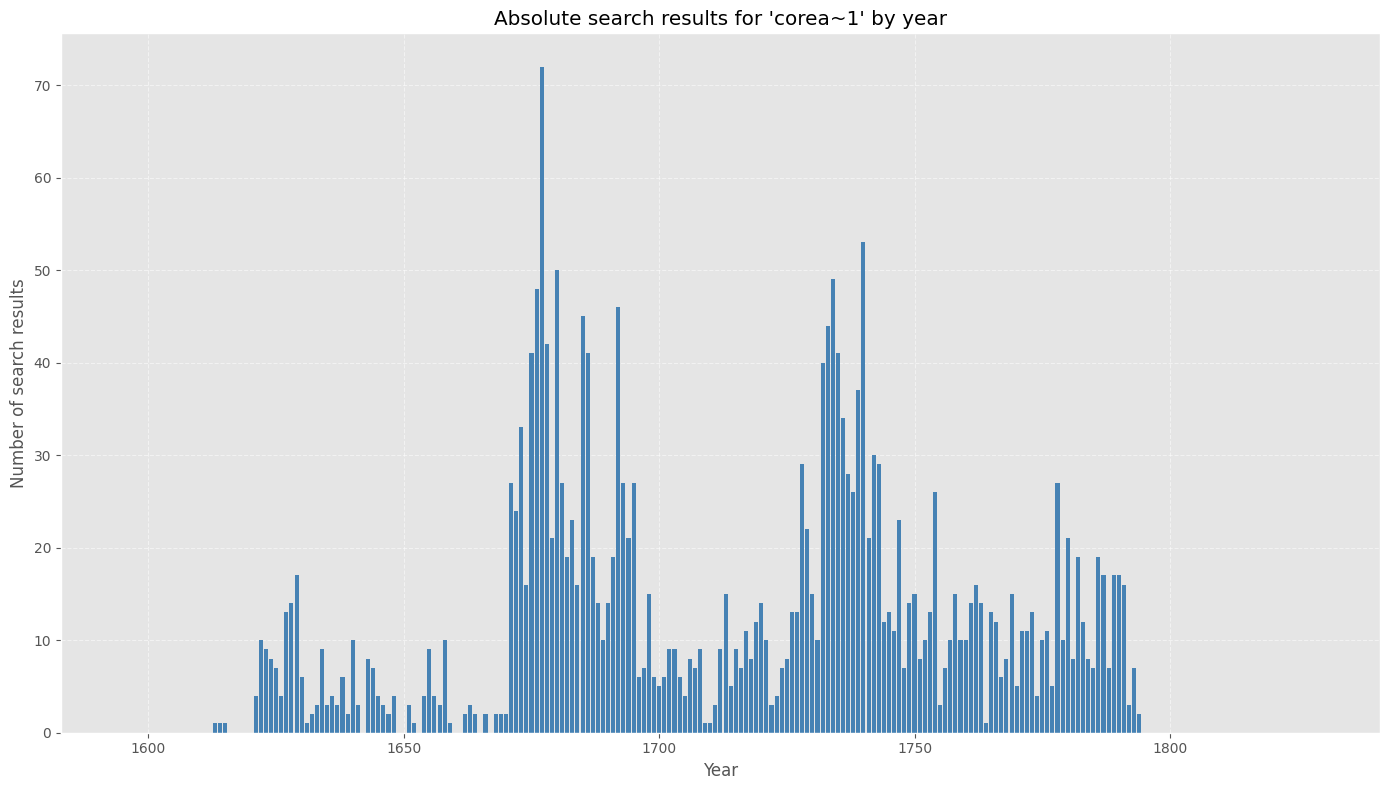

In [8]:
# Example 1: Single term with absolute counts (original)
yearly_data = visualizer.run("corea~1")


Searching for term: 'corea~1'
Fetching results 0 to 500
Total results: 2111
Fetching results 500 to 1000
Fetching results 1000 to 1500
Fetching results 1500 to 2000
Fetching results 2000 to 2500
Searching for term: 'coreers~2'
Fetching results 0 to 500
Total results: 210

Generating absolute visualization...


<Figure size 1400x800 with 0 Axes>

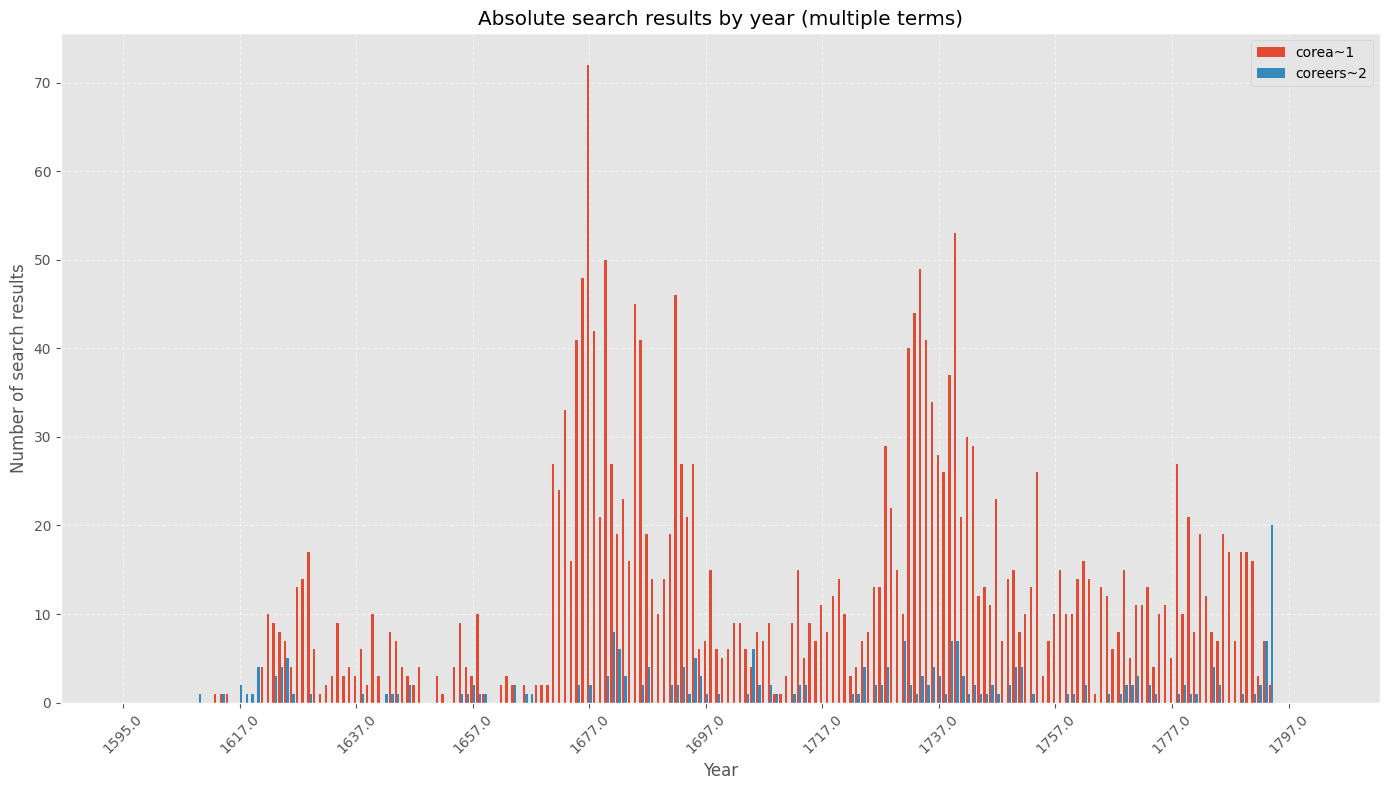

In [9]:
# Example 2: Multiple terms with separate visualization (original)
yearly_data = visualizer.run(["corea~1", "coreers~2"], plot_style="separate")

Searching for term: 'corea~1'
Fetching results 0 to 500
Total results: 2111
Fetching results 500 to 1000
Fetching results 1000 to 1500
Fetching results 1500 to 2000
Fetching results 2000 to 2500
Searching for term: 'coreers~2'
Fetching results 0 to 500
Total results: 210

Generating combined visualization...


<Figure size 1400x800 with 0 Axes>

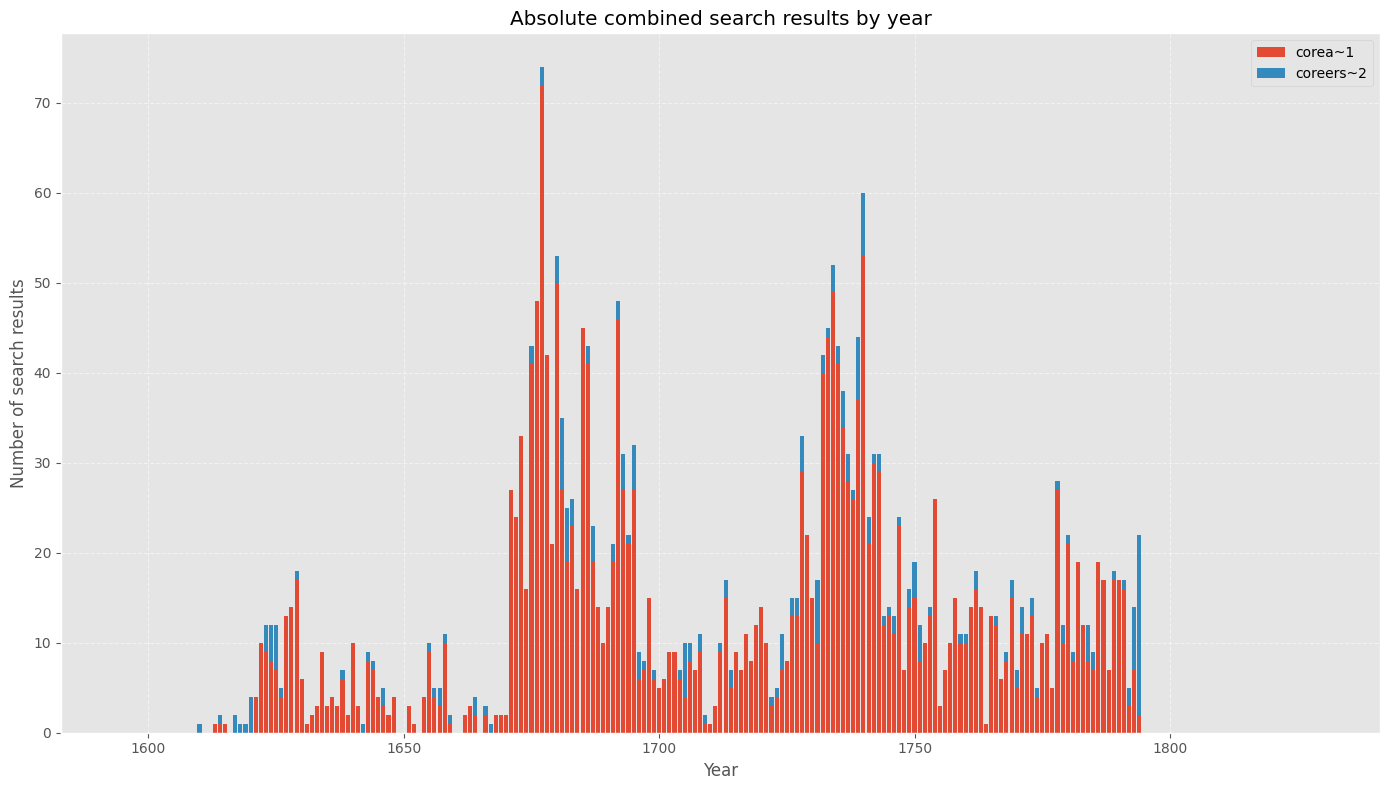

In [10]:
# Example 3: Single term with relative occurrences (new)
yearly_data = visualizer.run(["corea~1", "coreers~2"], visualization_types=["combined"])

Searching for term: 'corea~1'
Fetching results 0 to 500
Total results: 2111
Fetching results 500 to 1000
Fetching results 1000 to 1500
Fetching results 1500 to 2000
Fetching results 2000 to 2500

Generating relative visualization...


<Figure size 1400x800 with 0 Axes>

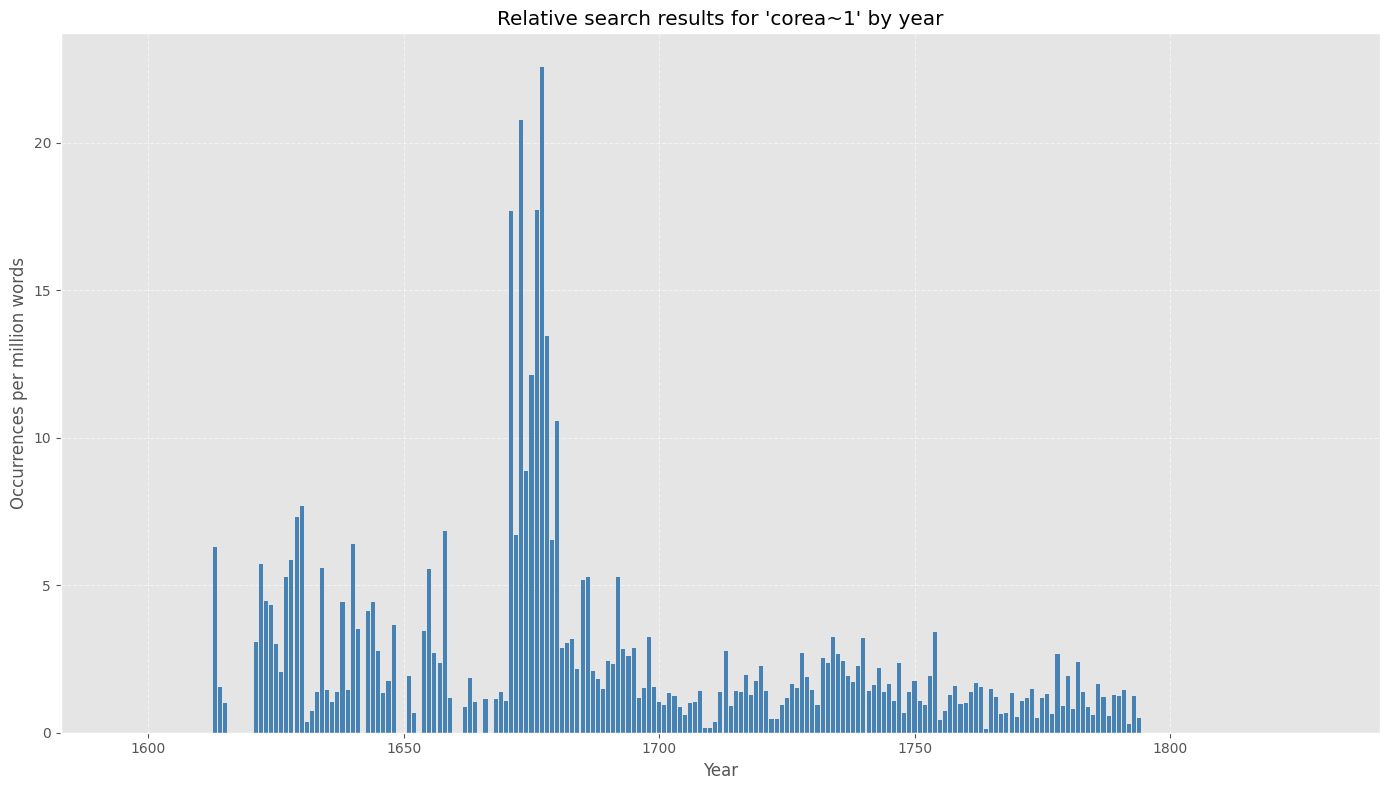

In [11]:
# Example 3: Single term with relative occurrences (new)
yearly_data = visualizer.run("corea~1", visualization_types=["relative"])

Searching for term: 'corea~1'
Fetching results 0 to 500
Total results: 2111
Fetching results 500 to 1000
Fetching results 1000 to 1500
Fetching results 1500 to 2000
Fetching results 2000 to 2500
Searching for term: 'coreers~2'
Fetching results 0 to 500
Total results: 210

Generating relative visualization...


<Figure size 1400x800 with 0 Axes>

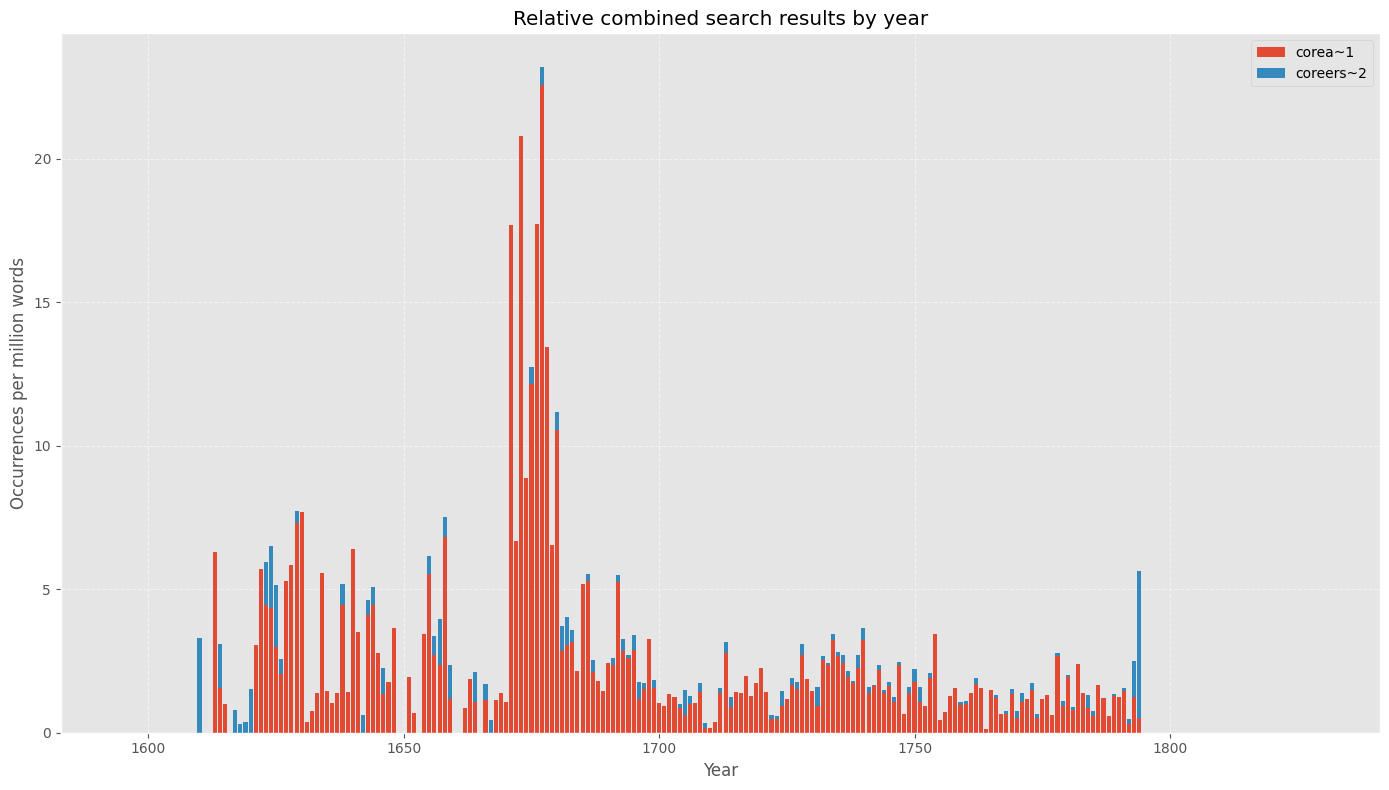

In [12]:
# Example 4: Multiple terms with combined relative occurrences (new)
yearly_data = visualizer.run(["corea~1", "coreers~2"], plot_style="combined", visualization_types=["relative"])

Searching for term: 'corea~1'
Fetching results 0 to 500
Total results: 2111
Fetching results 500 to 1000
Fetching results 1000 to 1500
Fetching results 1500 to 2000
Fetching results 2000 to 2500
Searching for term: 'coreers~2'
Fetching results 0 to 500
Total results: 210

Generating relative visualization...


<Figure size 1400x800 with 0 Axes>

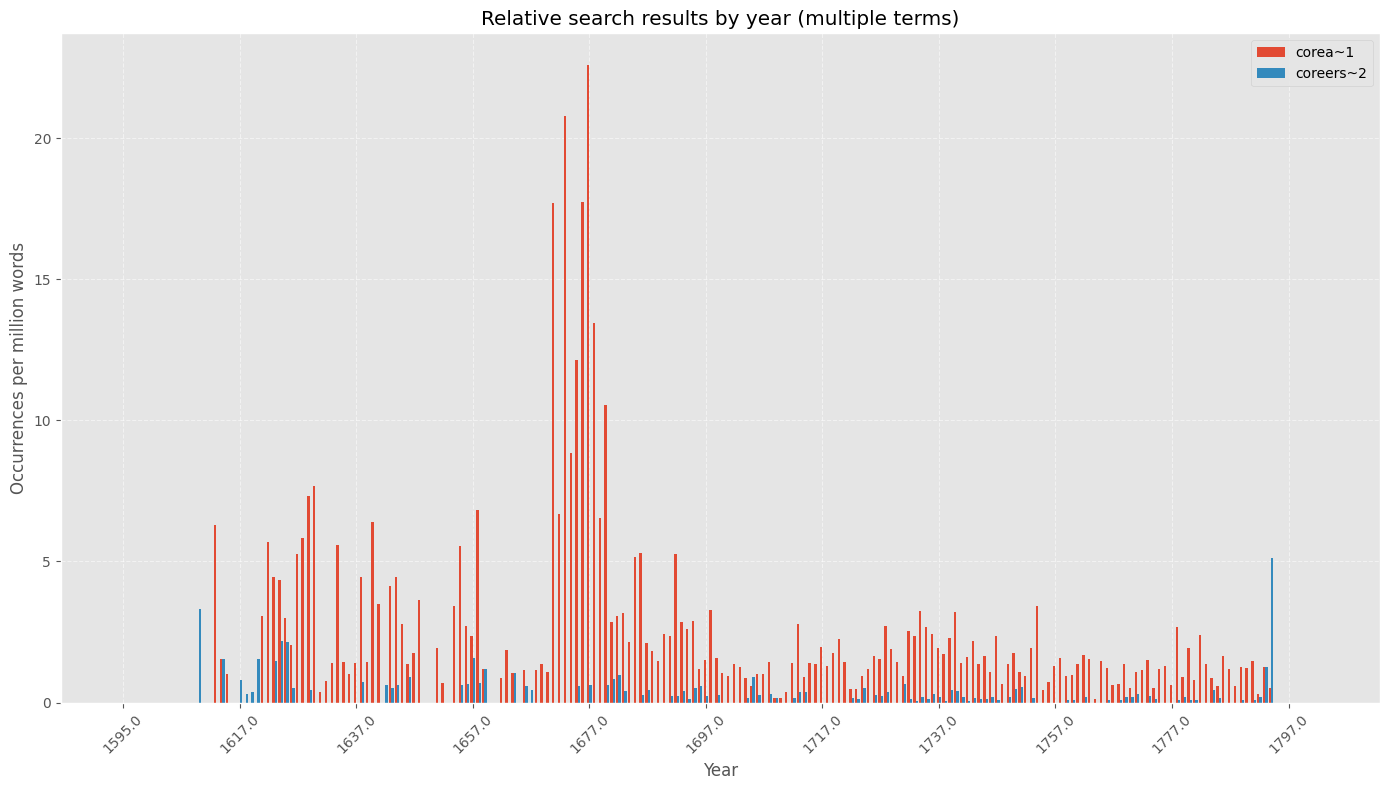

In [13]:
# Example 5: Multiple terms with separate relative occurrences (new)
yearly_data = visualizer.run(["corea~1", "coreers~2"], plot_style="separate", visualization_types=["relative"])

Searching for term: 'corea~1'
Fetching results 0 to 500
Total results: 2111
Fetching results 500 to 1000
Fetching results 1000 to 1500
Fetching results 1500 to 2000
Fetching results 2000 to 2500

Generating with_histogram visualization...


<Figure size 1400x800 with 0 Axes>

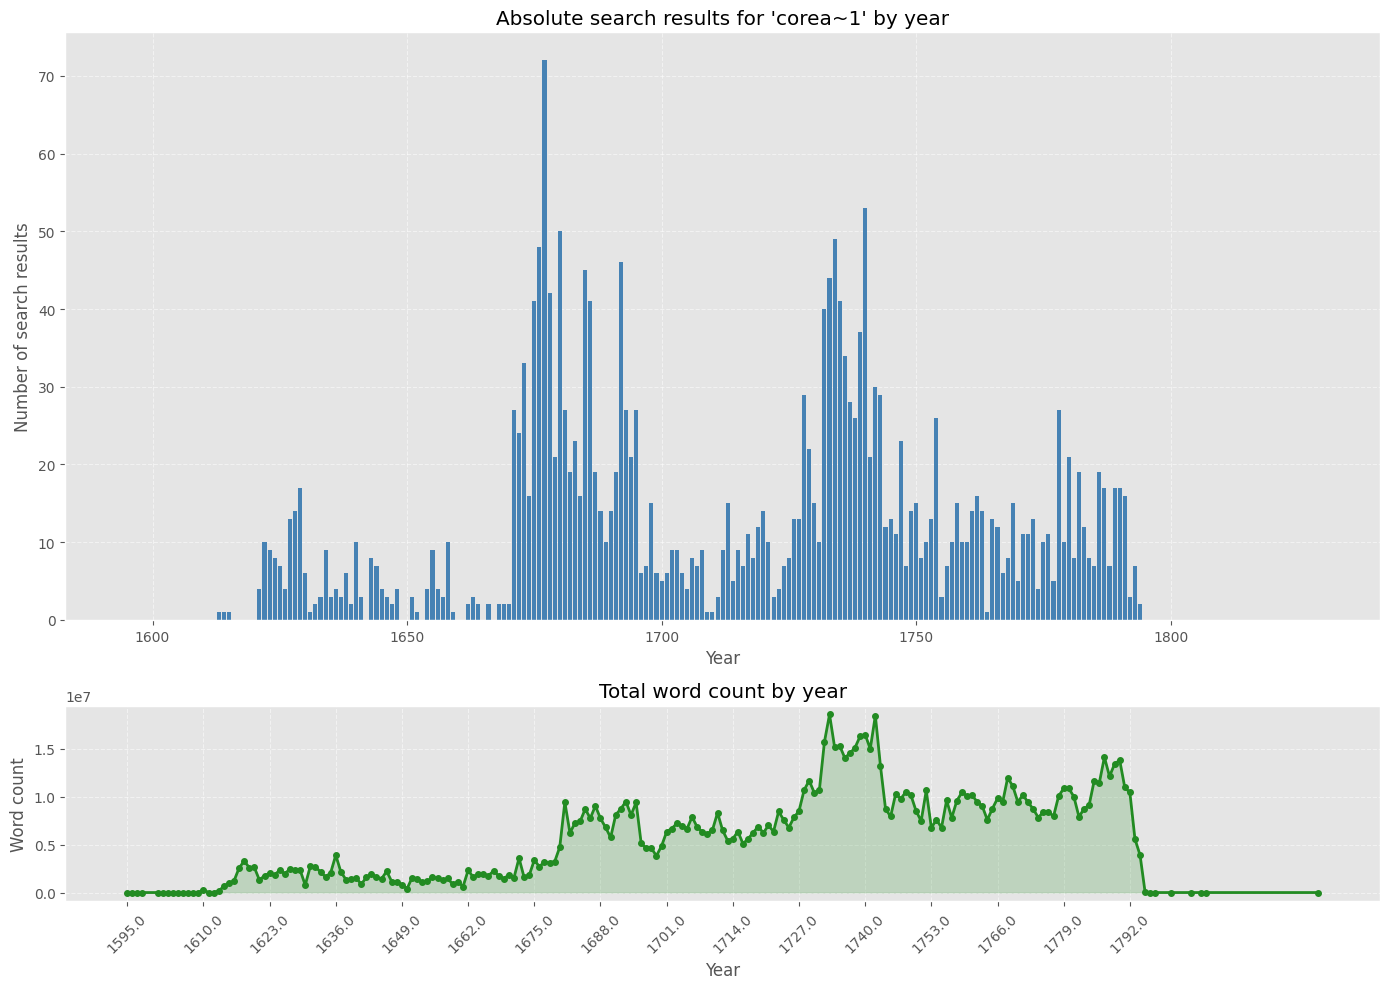

In [14]:

# Example 6: Single term with absolute counts and word count histogram (new)
yearly_data = visualizer.run("corea~1", visualization_types=["with_histogram"])

Searching for term: 'corea~1'
Fetching results 0 to 500
Total results: 2111
Fetching results 500 to 1000
Fetching results 1000 to 1500
Fetching results 1500 to 2000
Fetching results 2000 to 2500
Searching for term: 'coreers~2'
Fetching results 0 to 500
Total results: 210

Generating with_histogram visualization...


<Figure size 1400x800 with 0 Axes>

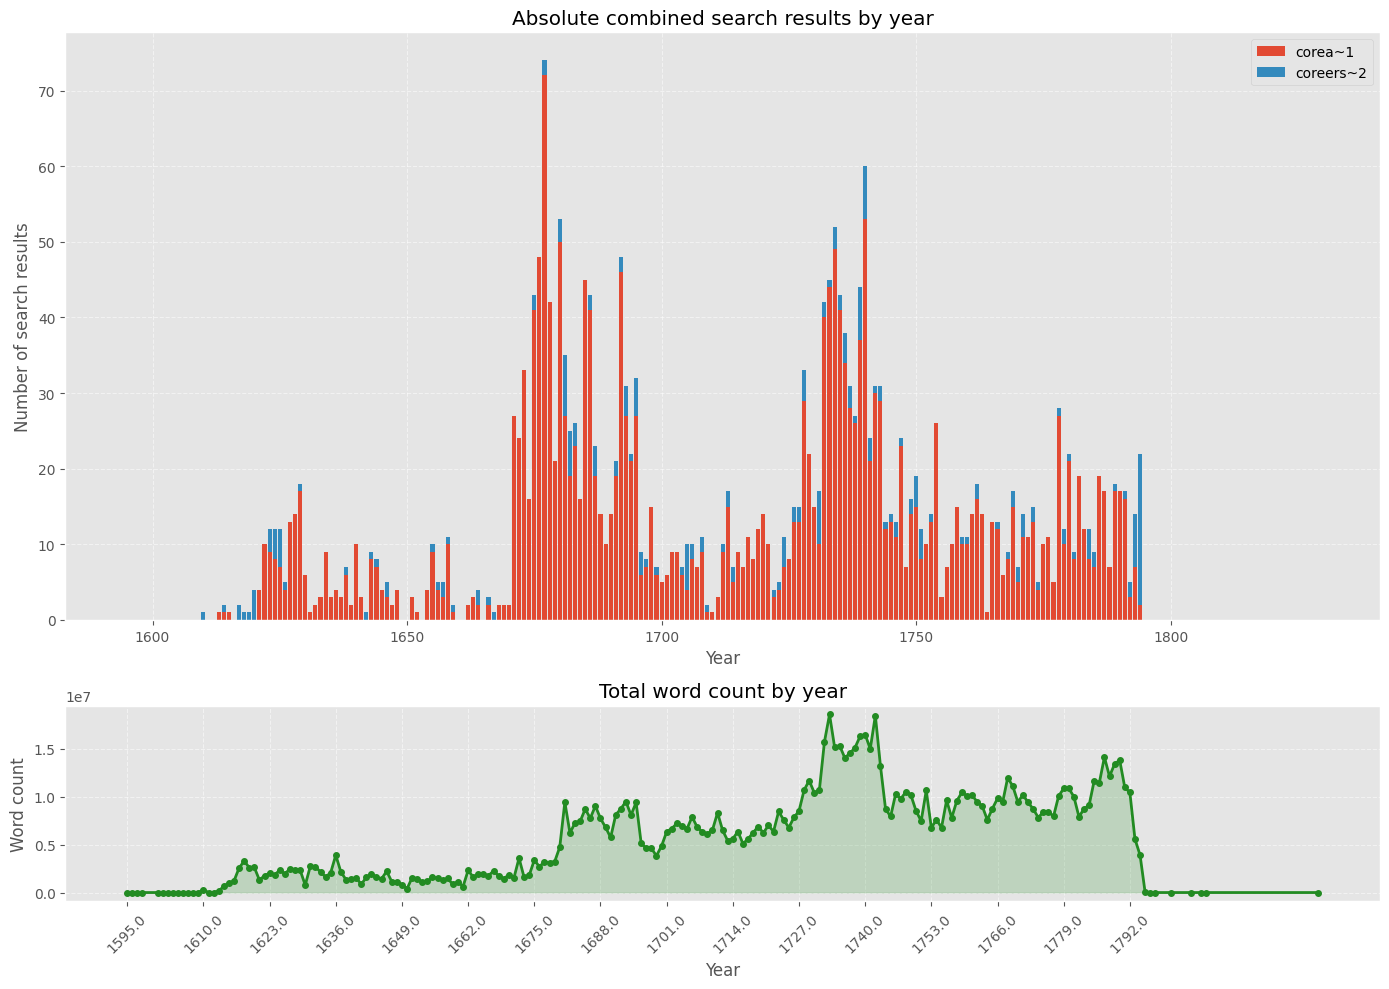

In [15]:
# Example 7: Multiple terms combined with word count histogram (new)
yearly_data = visualizer.run(["corea~1", "coreers~2"], plot_style="combined", visualization_types=["with_histogram"])

Searching for term: 'corea~1'
Fetching results 0 to 500
Total results: 2111
Fetching results 500 to 1000
Fetching results 1000 to 1500
Fetching results 1500 to 2000
Fetching results 2000 to 2500
Searching for term: 'coreers~2'
Fetching results 0 to 500
Total results: 210

Generating with_histogram visualization...


<Figure size 1400x800 with 0 Axes>

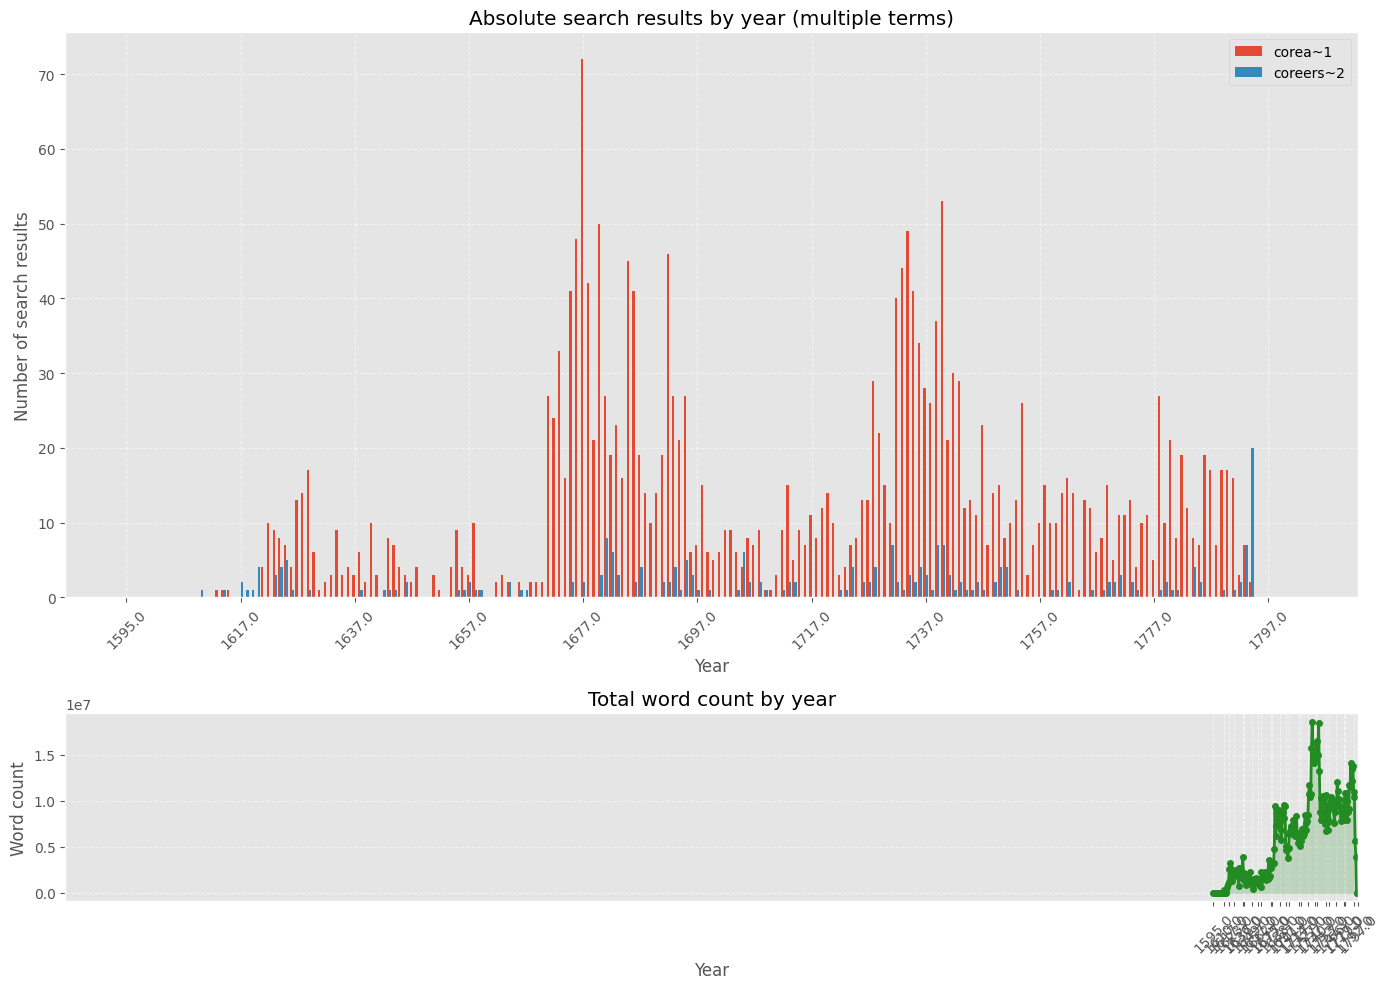

In [16]:
# Example 8: Multiple terms separate with word count histogram (new)
yearly_data = visualizer.run(["corea~1", "coreers~2"], plot_style="separate", visualization_types=["with_histogram"])

Searching for term: 'corea~1'
Fetching results 0 to 500
Total results: 2111
Fetching results 500 to 1000
Fetching results 1000 to 1500
Fetching results 1500 to 2000
Fetching results 2000 to 2500
Searching for term: 'coreers~2'
Fetching results 0 to 500
Total results: 210

Generating absolute visualization...


<Figure size 1400x800 with 0 Axes>

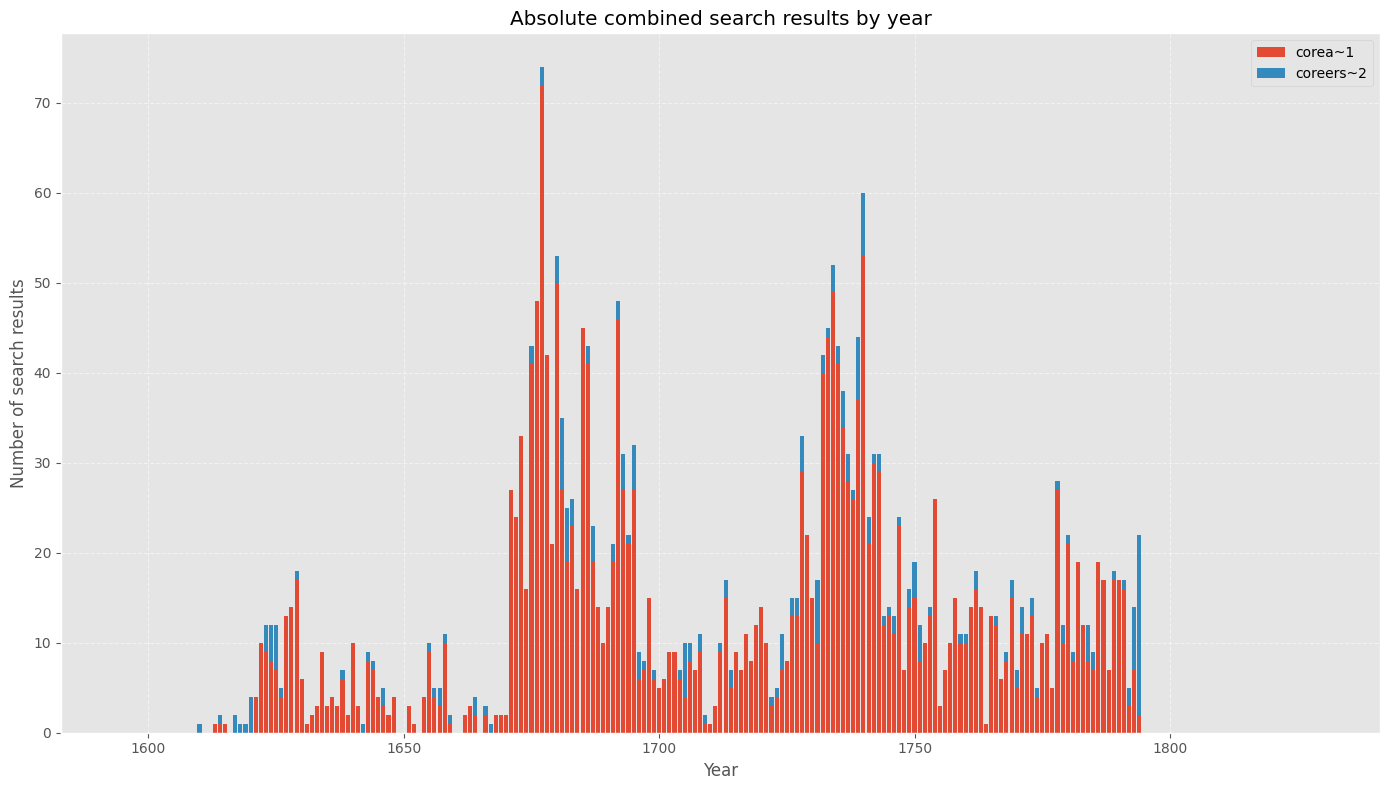


Generating relative visualization...


<Figure size 1400x800 with 0 Axes>

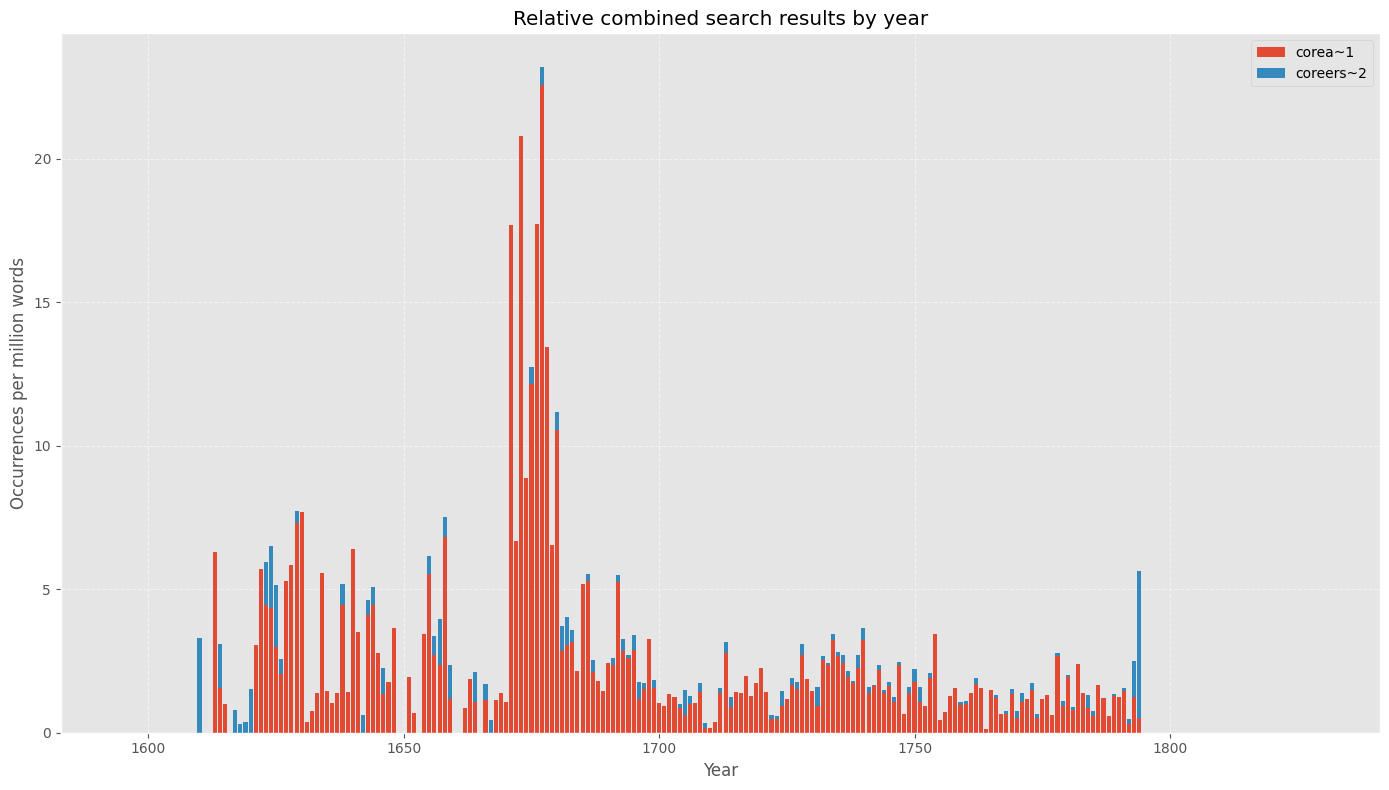


Generating with_histogram visualization...


<Figure size 1400x800 with 0 Axes>

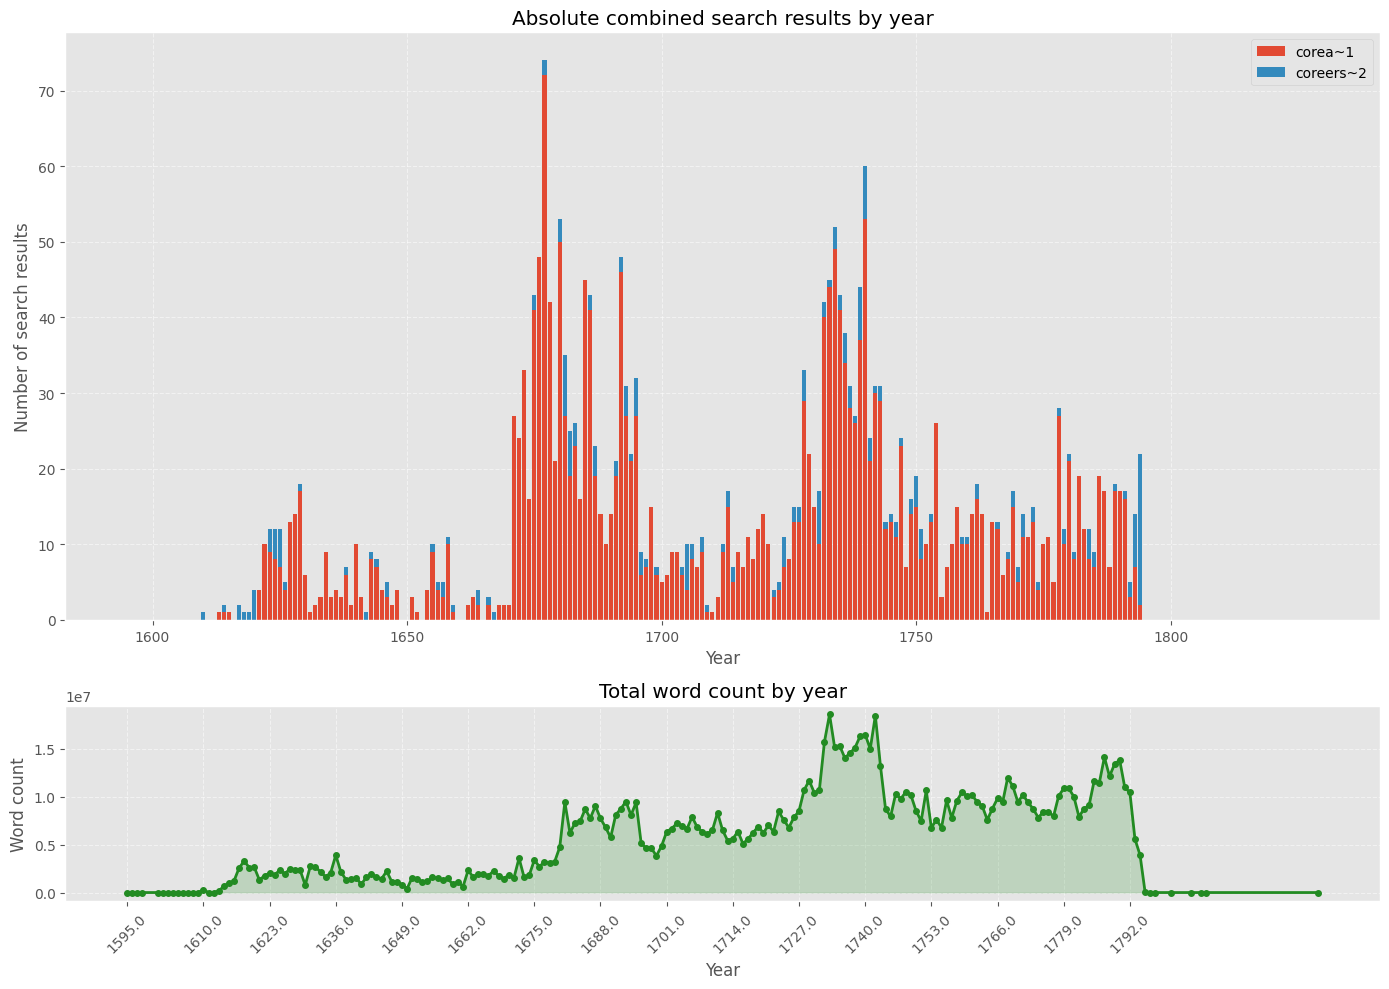

In [17]:
# Example 9: Generate all visualization types at once
yearly_data = visualizer.run(["corea~1", "coreers~2"], plot_style="combined", 
                            visualization_types=["absolute", "relative", "with_histogram"])